In [228]:
import cv2
import numpy as np
import matplotlib.pyplot as mp

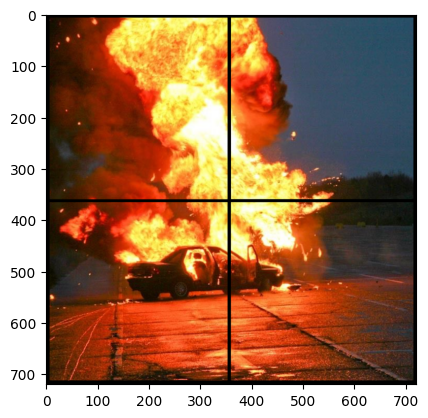

In [229]:
img = cv2.imread('Assets/Meledak.png')
meletup = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mp.imshow(meletup, cmap='gray')

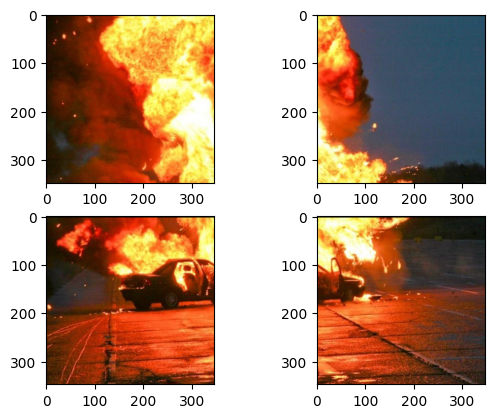

In [230]:
meletup1 = meletup[5:352, 5:352]
meletup2 = meletup[5:352, 363:710]
meletup3 = meletup[363:710, 5:352]
meletup4 = meletup[363:710, 363:710]

mp.subplot(2,2,1)
mp.imshow(meletup1, cmap='gray')
mp.subplot(2,2,2)
mp.imshow(meletup2, cmap='gray')
mp.subplot(2,2,3)
mp.imshow(meletup3, cmap='gray')
mp.subplot(2,2,4)
mp.imshow(meletup4, cmap='gray')

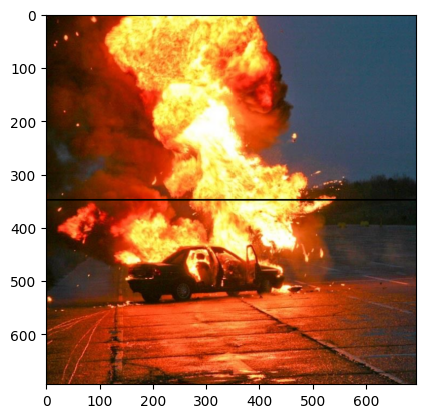

In [231]:
def merge_image(citra1, citra2, orientation='H'): 
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 

        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total,  citra1.shape[2]), dtype=citra1.dtype) 

        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0],  citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 

    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 

        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar,  citra1.shape[2]), dtype=citra1.dtype) 

        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 

    return gabungan

meletupgabung1 = merge_image(meletup1, meletup2, 'H')
meletupgabung2 = merge_image(meletup3, meletup4, 'H')
meletupgabung = merge_image(meletupgabung1, meletupgabung2,'V')
mp.imshow(meletupgabung)

In [232]:
print(f"Shape gambar: {meletupgabung.shape}")

Shape gambar: (694, 694, 3)


Shape gambar: (694, 694)


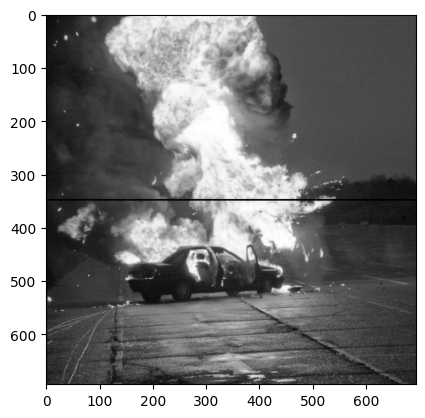

In [233]:
meletupabu = cv2.cvtColor(meletupgabung, cv2.COLOR_RGB2GRAY)
print(f"Shape gambar: {meletupabu.shape}")
mp.imshow(meletupabu, cmap='gray')

Shape gambar: (694, 694)


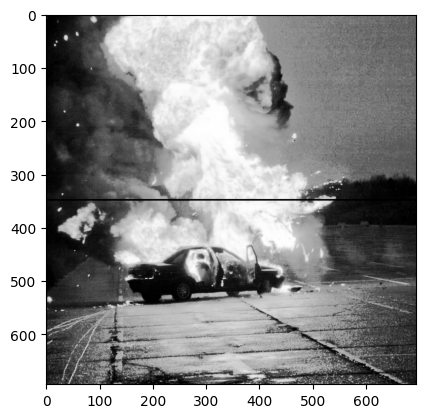

In [234]:
def ekualisasi(citra):

    height, width = citra.shape

    # Histogram
    hist = np.zeros(256, dtype=int)

    # Hitung histogram citra
    for i in range(height):
        for j in range(width):
            hist[int(citra[i, j])] += 1

    # CDF
    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]

    # Hitung CDF
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    # Normalisasi CDF
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)

    # Hasil ekualisasi
    hasil = np.zeros_like(citra, dtype=np.uint8)

    # Terapkan hasil CDF normalisasi
    for i in range(height):
        for j in range(width):
            hasil[i, j] = cdf_normal[int (citra[i, j])]

    return hasil

eq = ekualisasi(meletupabu)
print(f"Shape gambar: {eq.shape}")
mp.imshow(eq, cmap='gray')

In [235]:
def buat_hist(citra): 
    histogram = [0] * 256 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1   
    return histogram 

def plot_histogram(histogram, title, ImgColor): 
    mp.figure(figsize=(10, 5)) 
    mp.xlabel("Intensitas Piksel") 
    mp.title(title) 
    mp.ylabel("Jumlah Piksel") 
    mp.bar(range(256), histogram, color=ImgColor, width=0.8) 
    mp.show() 

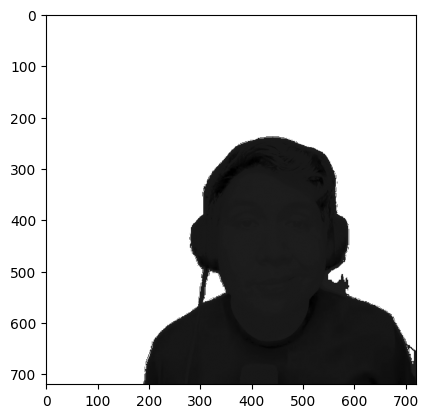

In [275]:
def spesifikasi_histogram(img_asli, img_target):
    # konversi ke grayscale di awal jika masih 3 channel
    if len(img_asli.shape) == 3:
        img_asli = cv2.cvtColor(img_asli.astype(np.uint8), cv2.COLOR_BGR2GRAY)
    if len(img_target.shape) == 3:
        img_target = cv2.cvtColor(img_target.astype(np.uint8), cv2.COLOR_BGR2GRAY)
    
    hist_asli = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    for i in range(img_asli.shape[0]):
        for j in range(img_asli.shape[1]):
            hist_asli[img_asli[i][j]] += 1

    for i in range(img_target.shape[0]):
        for j in range(img_target.shape[1]):
            hist_target[img_target[i][j]] += 1

    cdf_asli = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)
    cdf_asli[0] = hist_asli[0]
    cdf_target[0] = hist_target[0]

    for i in range(1, 256):
        cdf_asli[i] = cdf_asli[i-1] + hist_asli[i]
        cdf_target[i] = cdf_target[i-1] + hist_target[i]

    cdf_asli = cdf_asli / cdf_asli[-1]
    cdf_target = cdf_target / cdf_target[-1]

    map_hist = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        selisih_terkecil = float('inf')  # mulai dengan nilai tak terhingga
        j_terbaik = 0
        for j in range(256):
            selisih = abs(float(cdf_target[j]) - float(cdf_asli[i]))
            if selisih < selisih_terkecil:
                selisih_terkecil = selisih
                j_terbaik = j
        map_hist[i] = j_terbaik

    h, w = img_asli.shape[:2]
    hasil = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            hasil[i][j] = map_hist[img_asli[i][j]]

    return hasil

windut = cv2.imread('Assets/Windut.png')
windut = cv2.cvtColor(windut, cv2.COLOR_BGR2GRAY)
bunga = cv2.imread('Assets/Bunga.png')
spec = spesifikasi_histogram(windut, bunga)
mp.imshow(spec, cmap='gray')

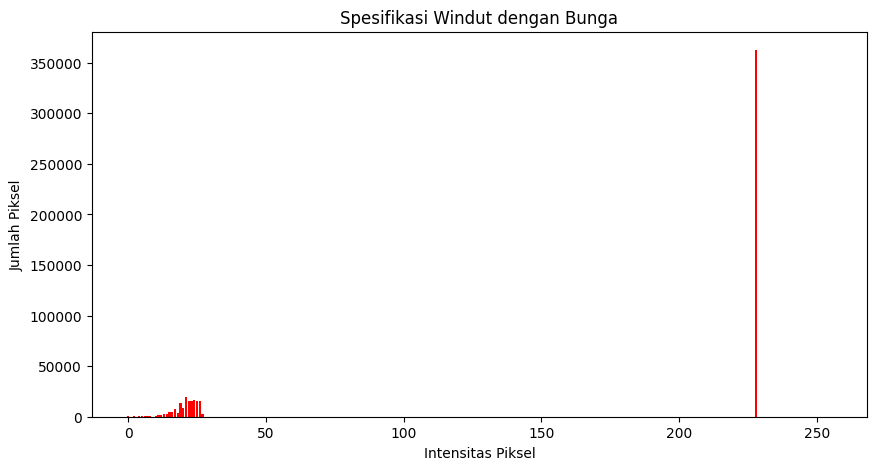

In [237]:
histspec = buat_hist(spec)
hist = plot_histogram(histspec, "Spesifikasi Windut dengan Bunga", 'red')

Text(0.5, 1.0, 'Masking Background')

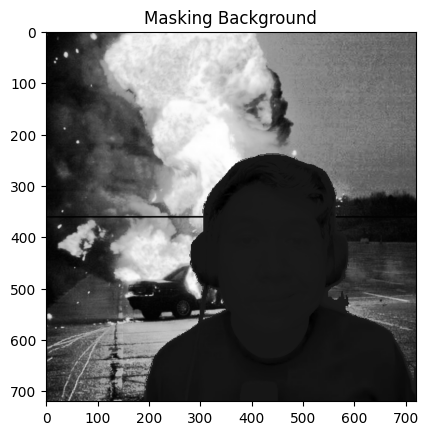

In [238]:
# resize biar sama
bg = cv2.resize(eq, (spec.shape[1], spec.shape[0]))

masking = np.zeros_like(img)

for i in range(spec.shape[0]):
    for j in range(spec.shape[1]):
        if spec[i, j] > 200:  # threshold bisa disesuaikan
            masking[i, j] = bg[i, j]
        else:
            masking[i, j] = spec[i, j]

mp.imshow(masking, cmap='gray')
mp.title("Masking Background")

Shape gambar: (720, 720, 3)


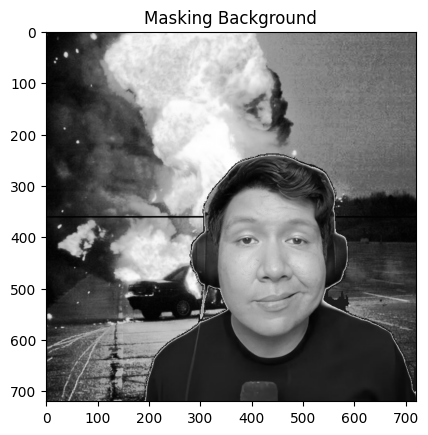

In [ ]:
jadi = cv2.resize(masking, (windut.shape[1], windut.shape[0]))

masking2 = np.zeros_like(img)

for i in range(windut.shape[0]):
    for j in range(windut.shape[1]):
        if windut[i, j] > 230:  # threshold bisa disesuaikan
            masking2[i, j] = jadi[i, j]
        else:
            masking2[i, j] = windut[i, j]

mp.imshow(masking2, cmap='gray')
mp.title("Masking Background")
print(f"Shape gambar: {masking2.shape}")

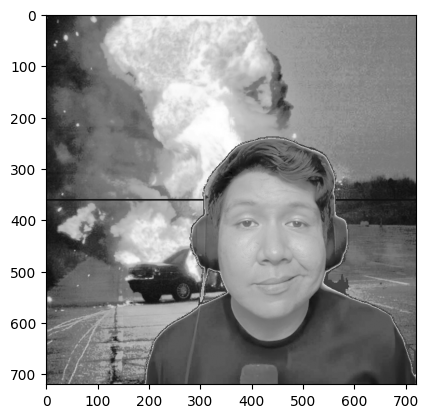

In [293]:
langit = cv2.imread('Assets/Langit.png')
langit = cv2.cvtColor(langit, cv2.COLOR_BGR2GRAY)

spec2 = spesifikasi_histogram(masking2, langit)
mp.imshow(spec2, cmap='gray')